# Customer Churn Prediction — Phase 4: Split, Scale & SMOTE

**The golden rule of ML evaluation:**  
> "The test set must simulate data the model has never seen.  
>  Any operation that uses test data to inform training is data leakage."

**Correct order of operations (strictly enforced here):**
```
1. Split X, y  →  X_train, X_test, y_train, y_test
2. Fit scaler  →  on X_train ONLY
3. Transform   →  BOTH X_train and X_test using train's stats
4. SMOTE       →  on (X_train_scaled, y_train) ONLY
5. Train model →  on SMOTE-balanced training set
6. Evaluate    →  on original (unbalanced) X_test
```

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

COLORS = {'no_churn': '#2C6E91', 'churn': '#E53935', 'bg': '#F7F9FC'}
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.facecolor'] = COLORS['bg']

X = pd.read_csv('../data/processed/X_preprocessed.csv')
y = pd.read_csv('../data/processed/y_target.csv').squeeze()  # squeeze: DataFrame → Series

with open('../data/processed/cols_to_scale.pkl', 'rb') as f:
    cols_to_scale = pickle.load(f)

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Columns to scale: {cols_to_scale}')

X shape : (7043, 23)
y shape : (7043,)
Columns to scale: ['tenure', 'MonthlyCharges', 'TotalCharges']


---
## Step 1 — Train-Test Split (80/20)

**Why 80/20?**  
With 7,043 samples, an 80/20 split gives us:
- Training: ~5,634 rows → enough for the model to learn patterns
- Testing:  ~1,409 rows → enough for statistically reliable evaluation

**Why `stratify=y`?**  
Without stratify, a random split might put 90% of churners in training and  
only 10% in test — by bad luck. `stratify=y` ensures both splits maintain  
the same 73%/27% churn ratio as the full dataset.

**Why `random_state=42`?**  
Reproducibility — anyone who clones your GitHub repo gets identical results.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y      # preserve churn ratio in both splits
)

print('Train-Test Split complete:')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print()
print('Churn distribution after stratified split:')
print(f'  y_train — Class 0: {(y_train==0).sum():,}  Class 1: {(y_train==1).sum():,}  Ratio: {(y_train==1).mean()*100:.1f}%')
print(f'  y_test  — Class 0: {(y_test==0).sum():,}   Class 1: {(y_test==1).sum():,}   Ratio: {(y_test==1).mean()*100:.1f}%')
print()
print('Churn ratio is preserved in both splits — stratify=y worked correctly.')

Train-Test Split complete:
  X_train : (5634, 23)
  X_test  : (1409, 23)

Churn distribution after stratified split:
  y_train — Class 0: 4,139  Class 1: 1,495  Ratio: 26.5%
  y_test  — Class 0: 1,035   Class 1: 374   Ratio: 26.5%

Churn ratio is preserved in both splits — stratify=y worked correctly.


---
## Step 2 — Fit & Apply StandardScaler

**The data leakage danger explained:**
```
BAD (leakage):
    scaler.fit_transform(X)          # learns mean/std from ALL data including test
    X_train, X_test = split(X_scaled) # too late — test info already leaked in

CORRECT:
    scaler.fit(X_train)              # learns mean/std from TRAINING data only
    X_train = scaler.transform(X_train)
    X_test  = scaler.transform(X_test)  # applies TRAIN stats to test — no leakage
```

**Why only scale 3 columns, not all 25?**  
The other 22 columns are binary (0 or 1). StandardScaler on a binary column  
would produce values like -0.58 and 1.72 — misleading for tree models,  
and unnecessary since the values are already on the same scale.

In [3]:
scaler = StandardScaler()

# Fit ONLY on training data
scaler.fit(X_train[cols_to_scale])

print('Scaler learned from training data:')
for col, mean, std in zip(cols_to_scale, scaler.mean_, scaler.scale_):
    print(f'  {col:<20} mean={mean:.2f}  std={std:.2f}')

# Apply to BOTH splits — but using ONLY training stats
X_train = X_train.copy()
X_test  = X_test.copy()

X_train[cols_to_scale] = scaler.transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print()
print('After scaling — training data stats (should be near mean≈0, std≈1):')
print(X_train[cols_to_scale].describe().loc[['mean','std']].round(3))

Scaler learned from training data:
  tenure               mean=32.49  std=24.57
  MonthlyCharges       mean=64.93  std=30.14
  TotalCharges         mean=2299.33  std=2279.00

After scaling — training data stats (should be near mean≈0, std≈1):
      tenure  MonthlyCharges  TotalCharges
mean    -0.0            -0.0           0.0
std      1.0             1.0           1.0


---
## Step 3 — SMOTE: Synthetic Minority Over-Sampling Technique

### The Problem
Our training set has 2.8:1 imbalance (73% No Churn : 27% Churn).  
A model trained on this sees 2.8× more "No Churn" examples and learns to favor that class.

### Why NOT just duplicate churner rows?
Simple oversampling copies existing churners. The model **memorizes** those specific rows  
instead of learning the *pattern* — this is overfitting.

### How SMOTE actually works (the math):
```
1. Pick a minority class sample (a churner): point A
2. Find its K nearest neighbors (also churners): B, C, D...
3. Pick one neighbor randomly: B
4. Create a synthetic point anywhere on the LINE between A and B:
   synthetic = A + random(0,1) × (B - A)
5. Repeat until classes are balanced
```
SMOTE creates **new, plausible churner profiles** that lie between real ones —  
not copies, but mathematically valid interpolations.

### Why NEVER apply SMOTE to the test set?
> The test set must reflect **real-world conditions** — where churn IS rare (27%).  
> If we balance the test set, we evaluate on a fantasy world where 50% churn.  
> Our model would appear to perform well in the lab but fail in production.  
> SMOTE is a **training trick** to help the model learn — never an evaluation tool.

In [4]:
print('Before SMOTE (training set):')
print(f'  Class 0 (No Churn): {(y_train==0).sum():,}')
print(f'  Class 1 (Churn)   : {(y_train==1).sum():,}')
print(f'  Imbalance ratio   : {(y_train==0).sum()/(y_train==1).sum():.2f}:1')

# Apply SMOTE — ONLY on training data
# k_neighbors=5 (default): each synthetic point is between a real minority
# sample and one of its 5 nearest minority neighbors.
# random_state=42: reproducibility
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print()
print('After SMOTE (training set):')
print(f'  Class 0 (No Churn): {(y_train_sm==0).sum():,}')
print(f'  Class 1 (Churn)   : {(y_train_sm==1).sum():,}')
print(f'  Imbalance ratio   : {(y_train_sm==0).sum()/(y_train_sm==1).sum():.2f}:1')
print()
print('Synthetic churner samples created:',
      (y_train_sm==1).sum() - (y_train==1).sum())
print()
print('Test set (UNCHANGED — real-world distribution):')
print(f'  Class 0 (No Churn): {(y_test==0).sum():,}')
print(f'  Class 1 (Churn)   : {(y_test==1).sum():,}')

Before SMOTE (training set):
  Class 0 (No Churn): 4,139
  Class 1 (Churn)   : 1,495
  Imbalance ratio   : 2.77:1

After SMOTE (training set):
  Class 0 (No Churn): 4,139
  Class 1 (Churn)   : 4,139
  Imbalance ratio   : 1.00:1

Synthetic churner samples created: 2644

Test set (UNCHANGED — real-world distribution):
  Class 0 (No Churn): 1,035
  Class 1 (Churn)   : 374


---
## Step 4 — Visualize: Before vs After SMOTE

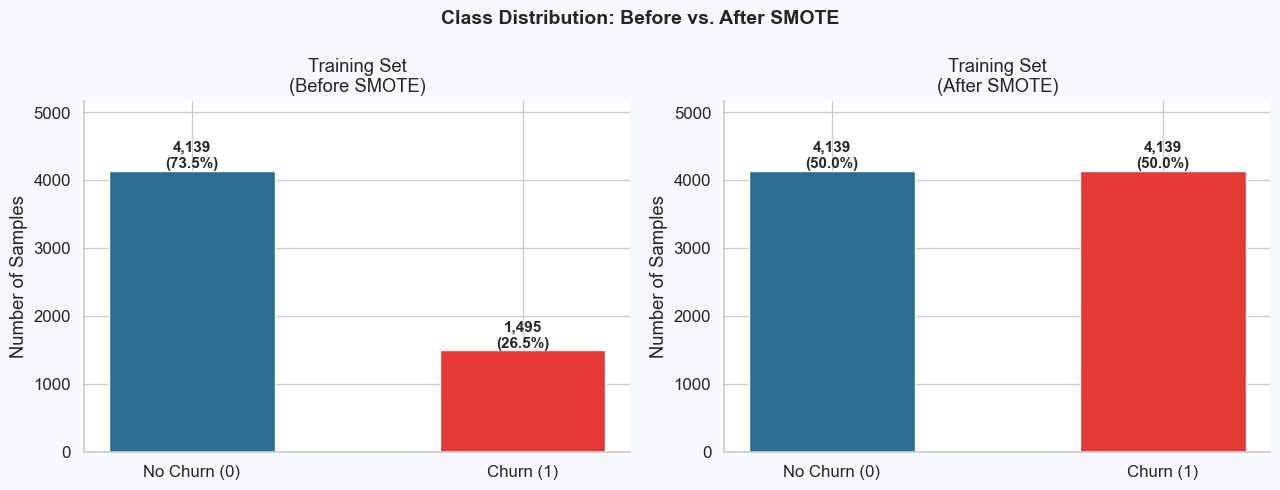

Chart saved: docs/charts/07_smote_balance.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Class Distribution: Before vs. After SMOTE', fontsize=14, fontweight='bold')

datasets = [
    (y_train,    'Training Set\n(Before SMOTE)', axes[0]),
    (y_train_sm, 'Training Set\n(After SMOTE)',  axes[1]),
]

for y_data, title, ax in datasets:
    counts = pd.Series(y_data).value_counts().sort_index()
    labels = ['No Churn (0)', 'Churn (1)']
    colors = [COLORS['no_churn'], COLORS['churn']]

    bars = ax.bar(labels, counts.values, color=colors,
                  edgecolor='white', width=0.5)
    for bar, count in zip(bars, counts.values):
        pct = count / counts.sum() * 100
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 40,
                f'{count:,}\n({pct:.1f}%)',
                ha='center', fontweight='bold', fontsize=11)

    ax.set_title(title)
    ax.set_ylabel('Number of Samples')
    ax.set_ylim(0, counts.max() * 1.25)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../docs/charts/07_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: docs/charts/07_smote_balance.png')

---
## Step 5 — Save All Splits

In [6]:
# Convert to numpy arrays for model training (sklearn convention)
# Also save scaler for later use in production/inference
splits = {
    'X_train_sm' : X_train_sm,     # SMOTE-balanced training features
    'y_train_sm' : y_train_sm,     # SMOTE-balanced training labels
    'X_test'     : X_test,         # Original (unbalanced) test features
    'y_test'     : y_test,         # Original (unbalanced) test labels
    'X_train'    : X_train,        # Scaled but pre-SMOTE (for reference)
    'y_train'    : y_train,
    'feature_names': list(X.columns),
    'scaler'     : scaler,
}

with open('../data/processed/train_test_splits.pkl', 'wb') as f:
    pickle.dump(splits, f)

print('Saved: data/processed/train_test_splits.pkl')
print()
print('=' * 55)
print(' PHASE 4 SUMMARY')
print('=' * 55)
print(f' X_train (pre-SMOTE)  : {X_train.shape}')
print(f' X_train (post-SMOTE) : {X_train_sm.shape}')
print(f' X_test  (unchanged)  : {X_test.shape}')
print(f' Features             : {X_train_sm.shape[1]}')
print(f' Synthetic samples    : {len(X_train_sm) - len(X_train):,}')
print(f' Test churn rate      : {y_test.mean()*100:.1f}% (real-world)')
print('=' * 55)
print(' Phase 4 Complete. Proceed to 05_model_training.ipynb')

Saved: data/processed/train_test_splits.pkl

 PHASE 4 SUMMARY
 X_train (pre-SMOTE)  : (5634, 23)
 X_train (post-SMOTE) : (8278, 23)
 X_test  (unchanged)  : (1409, 23)
 Features             : 23
 Synthetic samples    : 2,644
 Test churn rate      : 26.5% (real-world)
 Phase 4 Complete. Proceed to 05_model_training.ipynb
